<a href="https://colab.research.google.com/github/sally03915/2026-AI-Analysis-Lab/blob/main/AI-FlowTransformation/Step1-Math/basic004_%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%9D%98_%EC%97%B0%EC%87%84_%EC%98%A4%EB%8B%B5%EB%85%B8%ED%8A%B8_%EC%9E%91%EC%84%B1%EB%B2%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 👨‍🍳 데이터 분석 레스토랑: basic004_딥러닝의_연쇄_오답노트_작성법 (Chain Rule)

앞서 **basic003**에서 우리는 오븐의 화력을 미세하게 조절하기 위해 **미분(민감도 체크)** 과 **경사하강법(골짜기 내려가기)** 이 필요하다는 것을 배웠습니다.

그런데 실제 인공지능 주방(딥러닝)은 가스레인지 다이얼 하나만 돌린다고 요리가 끝나지 않습니다. **"가스 밸브 열기 ➡️ 가스레인지 다이얼 돌리기 ➡️ 오븐 문 열기"** 처럼 여러 주방 기구들이 사슬(Chain)처럼 줄줄이 연결되어 있죠. 최종 요리가 탔을 때, 대체 어떤 범인(다이얼) 때문에 요리가 망했는지 거꾸로 추적하며 오답 노트를 적는 마법이 바로 **합성함수의 미분(Chain Rule, 체인 룰)** 입니다.



<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>


### 1. Chain Rule: "범인은 이 안에 있어! 연쇄 오답 노트" 🔗

복잡한 수학 기호는 다 던져버리세요. 주방에서 일어난 연쇄 반응으로 이해하면 아주 쉽습니다.

* **상황:** 오늘 구운 쿠키가 새까맣게 타서 오차가 너무 크게 나왔습니다(크로스 엔트로피 벌점 폭탄!).
* **원인 추적:** 1. 가스 밸브를 너무 세게 열었더니 ($\Delta x$),
  2. 가스레인지로 들어가는 가스양이 너무 많아졌고 ($\Delta y$),
  3. 그 바람에 오븐 온도가 미쳐 날뛰어서 쿠키가 탔습니다 ($\Delta z$).



최종 결과인 **쿠키의 상태($z$)** 를 바꾸려면, 맨 처음에 있는 **가스 밸브($x$)** 를 얼마나 조절해야 할까요?

> 💡 **체인 룰(Chain Rule)의 핵심:**
> "가스 밸브를 살짝 움직였을 때 가스양이 변하는 민감도($\frac{dy}{dx}$)"와 "가스량이 변했을 때 오븐 온도가 변하는 민감도($\frac{dz}{dy}$)"를 **줄줄이 곱해주기만 하면** ($\frac{dz}{dy} \times \frac{dy}{dx} = \frac{dz}{dx}$) 맨 처음 가스 밸브가 최종 요리에 미친 영향력을 한 번에 계산할 수 있습니다!

수학자들이 말하는 합성함수 미분이니 $dy/dx$니 하는 기호들은, 그냥 **"앞에서 일어난 나비효과(민감도)들을 중간 과정 생략하고 맨 뒤에서 맨 앞까지 도미노처럼 곱해 나가는 규칙"** 일 뿐입니다. 컴퓨터는 이 연쇄 법칙 덕분에 아무리 깊고 복잡한 신경망이라도 지치지 않고 오답 노트를 계산해 냅니다.


In [ ]:
### 1. 간단버젼
#   - 가스 밸브를 조금 열면 → 가스가 늘어나고 → 오븐 온도가 올라가서 → 쿠키가 탄다.
#   - 즉, “앞에서 조금 건드린 게 뒤에서 크게 영향을 준다”는 걸 추적하는 규칙이 체인 룰입니다.

# 간단한 연쇄 반응 흉내

x = 2   # 가스 밸브
y = x * 3   # 가스량
z = y + 5   # 오븐 온도

print("x=", x, "y=", y, "z=", z)

# 👉 의미: x(밸브)를 바꾸면 y(가스량), z(온도)가 줄줄이 변합니다.


x= 2 y= 6 z= 11


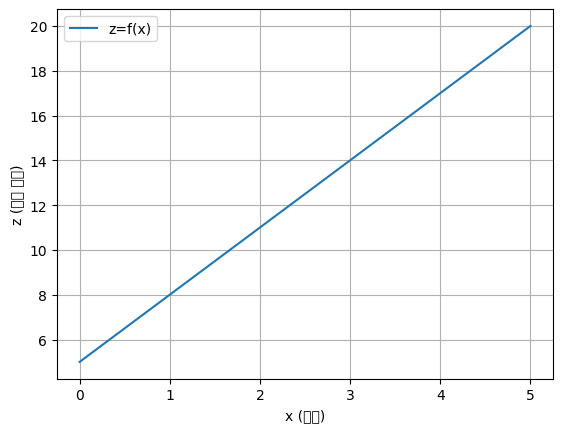

In [ ]:
### 2. 수학 버전 (공식 + 그래프)
# → “앞에서 건드린 변화가 뒤까지 어떻게 전달되는지 곱해서 계산한다.”

import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(0, 5, 100)
y_vals = 3*x_vals
z_vals = y_vals + 5

plt.plot(x_vals, z_vals, label="z=f(x)")
plt.xlabel("x (밸브)")
plt.ylabel("z (오븐 온도)")
plt.legend()
plt.grid(True)
plt.show()

# 👉 의미: x가 변하면 y, z가 줄줄이 변하는 걸 그래프로 확인


In [ ]:
### 3. 딥러닝 연결 (경사하강법 + 체인 룰)
# - **설명:** 딥러닝은 여러 층(layer)이 연결된 합성함수입니다.
#   - 입력 → 은닉층 → 출력
#   - 체인 룰 덕분에 “출력 오차”가 어디서 생겼는지 거꾸로 추적해서 각 층의 가중치를 고칠 수 있습니다.

# y = 3x, z = y + 5

def dy_dx(x):
    return 3

def dz_dy(y):
    return 1

def dz_dx(x):
    return dz_dy(3*x) * dy_dx(x)

print("dz/dx =", dz_dx(2))

# 👉 의미: “밸브(x)를 조금 움직였을 때 최종 온도(z)가 얼마나 변하는지”를 체인 룰로 계산


dz/dx = 3




<br/>
<br/>
<br/>


## 📌 001. 미분의 성질 (Derivative Rules 표)
- **수학적 의미:** 상수, 곱셈, 거듭제곱, 합, 차, 곱, 체인 룰 등 기본 미분 규칙을 정리한 표.  
- **생활 비유:**  
  - 상수 → “고정된 주방 가구는 변하지 않으니 미분하면 0”  
  - 곱셈 → “주방장과 조수가 협동할 때 실수 지분을 나누는 공식”  
  - 체인 룰 → “앞에서 건드린 변화가 뒤까지 도미노처럼 전달”  
- **딥러닝 연결:** 딥러닝은 여러 층이 연결된 합성함수 → 체인 룰 덕분에 오차를 거꾸로 추적 가능.  




#### 🦍 **딥러닝에서의 역할 (1):**

딥러닝 모델은 수많은 작은 계산들이 겹겹이 쌓여 있는 복잡한 함수와 같습니다. 이 표에 있는 상수, 곱셈, 체인 룰 같은 기본적인 미분 규칙들은 그 복잡한 함수의 '오차(실수)'를 찾아내고 고치기 위한 가장 기본적인 도구이자 재료들입니다. 마치 건축물이 벽돌 하나하나로 이루어지듯, 딥러닝의 복잡한 학습 과정은 이런 기본 미분 규칙들의 조합으로 이루어져 있습니다.

#### 🦍 **더 쉽게 풀어보는 미분의 성질 (2) 딥러닝 예시:**

딥러닝 모델이 복잡한 '미로'를 통과하여 정답을 찾아가는 과정이라고 생각해봅시다. 미로 안에는 여러 '길'과 '함정'이 있습니다. '미분의 성질'은 이 미로의 지도를 해독하는 기본적인 규칙들과 같습니다. 어떤 길은 항상 직선이고(상수 규칙), 어떤 길은 여러 갈래로 나뉘고(곱셈 규칙), 어떤 길은 다른 길과 연결되어 있습니다(체인 룰). 딥러닝 모델은 이 규칙들을 사용하여 미로 속에서 '어디가 잘못되었는지', 그리고 '어떻게 길을 수정해야 하는지'를 판단하는 기본적인 지식을 얻게 됩니다.

#### 🦍 **더더 쉽게 풀어보는 미분의 성질 (3) 딥러닝 예시::**

딥러닝은 마치 복잡한 '로봇 조립 공정'과 같습니다. 이 공정에는 나사 조이기, 용접하기, 페인트칠하기 등 여러 기본 작업들이 있습니다. '미분의 성질'은 이 기본 작업들을 위한 '작업 지침서'와 같습니다. 나사 조이는 방법(상수), 두 부품을 결합하는 방법(곱셈), 여러 작업을 순서대로 진행하는 방법(체인 룰) 등이 이 지침서에 적혀 있죠. 딥러닝 모델은 이 지침서를 바탕으로 각 작업에서 발생한 '실수(오차)'를 어떻게 찾아내고 수정해야 할지 배우게 됩니다.

### 🧪 1-1. 미분의 성질 (상수 규칙 예시 - 사칙연산 버전)

**비유:** "고정된 주방 가구는 변하지 않으니 미분하면 0"

주방의 냉장고 온도가 항상 5도로 고정되어 있다고 상상해 봅시다. 시간이 아무리 흘러도 냉장고 온도는 변하지 않습니다. 이처럼 '변하지 않는 것'의 변화율(미분)은 항상 0입니다.

In [ ]:
def f(x):
    return 99   # 항상 같은 값

def f_prime(x):
    return 0    # 변하지 않으니 변화율은 0

print("f(10) =", f(10))       # 99
print("f'(10) =", f_prime(10)) # 0


f(10) = 99
f'(10) = 0


In [ ]:
fixed_fridge_temp = 5 # 냉장고 온도 (변하지 않는 상수)

# 시간의 흐름에 따른 냉장고 온도의 변화량 (미분)은 얼마일까요?
# 상수는 변하지 않으므로, 변화량은 항상 0입니다.

derivative_of_constant = 0

print(f"고정된 냉장고 온도: {fixed_fridge_temp}도")
print(f"시간에 따른 냉장고 온도의 변화율 (미분): {derivative_of_constant}")
# 👉 의미: 어떤 값이 변하지 않고 고정되어 있다면, 그 값의 변화율은 0입니다.

고정된 냉장고 온도: 5도
시간에 따른 냉장고 온도의 변화율 (미분): 0


### 🧪 1-2. 미분의 성질 (곱셈 규칙 예시 - 사칙연산 버전)

**비유:** "주방장과 조수가 협동할 때 실수 지분을 나누는 공식"

쿠키의 맛을 결정하는 두 가지 요소가 있다고 해봅시다. '재료의 신선도'와 '굽는 기술'입니다.

*   **주방장 (g):** 재료의 신선도를 담당
*   **조수 (h):** 굽는 기술을 담당

최종 쿠키의 맛(f)은 이 둘의 곱으로 결정됩니다. 만약 쿠키 맛이 이상할 때, 주방장과 조수가 각자 어느 정도의 '책임(변화 기여도)'을 가지고 있는지 계산하는 것이 곱셈 규칙입니다.

In [ ]:
def f(x):
    return 3*x   #  x가 1단위 변할 때마다 f(x)는 항상 3단위씩 변합니다

def f_prime(x):
    return 3    # 항상 3  - 이 함수의 변화율, 즉 미분값이 항상 3으로 일정하다는 의미입니다. 어떤 지점의 x 값이든 이 함수의 기울기는 늘 3인

# f(x) = c * x 형태의 함수를 미분하면 f'(x) = c가 된다는 '상수배 규칙' 또는 '멱함수 규칙의 특수한 경우'
print("f(5) =", f(5))        # 15
print("f'(5) =", f_prime(5)) # 3


f(5) = 15
f'(5) = 3


In [ ]:
# x 값은 지금은 단순히 '상황'을 나타내는 변수라고 생각합시다.  예) 오븐의 온도 설정
x = 2

# 주방장 (재료 신선도)의 기여도 함수 g(x)
g_x = 2 * x      # x가 1 변하면 g_x는 2 변합니다. 즉 g'(x) = 2
dg_dx = 2

# 조수 (굽는 기술)의 기여도 함수 h(x)
h_x = x + 3      # x가 1 변하면 h_x는 1 변합니다. 즉 h'(x) = 1
dh_dx = 1

print(f"현재 주방장 기여도 g(x) = {g_x} (x={x}일 때)")
print(f"현재 조수 기여도 h(x) = {h_x} (x={x}일 때)\n")

# 최종 쿠키 맛 f(x) = g(x) * h(x)
# 곱셈 규칙: f'(x) = g'(x) * h(x) + g(x) * h'(x)

# 1단계: 주방장이 얼마나 잘못했는지 (g'(x) * h(x))
chef_mistake_contribution = dg_dx * h_x
print(f"1. 주방장의 '책임' 부분 (g'(x) * h(x)): {dg_dx} * {h_x} = {chef_mistake_contribution}")

# 2단계: 조수가 얼마나 잘못했는지 (g(x) * h'(x))
assistant_mistake_contribution = g_x * dh_dx
print(f"2. 조수의 '책임' 부분 (g(x) * h'(x)): {g_x} * {dh_dx} = {assistant_mistake_contribution}")

# 3단계: 최종 쿠키 맛의 변화율 (총 책임)
total_flavor_change = chef_mistake_contribution + assistant_mistake_contribution
print(f"\n3. 최종 쿠키 맛의 변화율 (f'(x) = 총 책임): {total_flavor_change}")

# 👉 의미: 최종 쿠키 맛의 변화는 주방장의 변화율에 조수의 현재 기여도를 곱한 것과,
#         조수의 변화율에 주방장의 현재 기여도를 곱한 것을 더한 것과 같습니다.

현재 주방장 기여도 g(x) = 4 (x=2일 때)
현재 조수 기여도 h(x) = 5 (x=2일 때)

1. 주방장의 '책임' 부분 (g'(x) * h(x)): 2 * 5 = 10
2. 조수의 '책임' 부분 (g(x) * h'(x)): 4 * 1 = 4

3. 최종 쿠키 맛의 변화율 (f'(x) = 총 책임): 14


### 🧪 1-3. 미분의 성질 (체인 룰 예시 - 사칙연산 버전)

우리가 `dz_dx` 함수에서 계산했던 "밸브(x)를 살짝 움직였을 때 최종 온도(z)가 얼마나 변하는지"를 사칙연산으로 직접 따라가 봅시다.

`x = 2` 일 때,

1.  **가스 밸브(x)를 조절했을 때 가스량(y)이 얼마나 변하는지** (`dy/dx`)
    *   `y = 3 * x` 이므로, `x`가 1만큼 변하면 `y`는 3만큼 변합니다. 즉, `dy/dx = 3` 입니다.

2.  **가스량(y)이 변했을 때 오븐 온도(z)가 얼마나 변하는지** (`dz/dy`)
    *   `z = y + 5` 이므로, `y`가 1만큼 변하면 `z`도 1만큼 변합니다. 즉, `dz/dy = 1` 입니다.

3.  **최종적으로 가스 밸브(x)가 오븐 온도(z)에 미치는 영향** (`dz/dx`)
    *   이 두 변화량을 곱해주면 됩니다! (`dz/dy * dy/dx`)


In [ ]:
def f(x):
    return x**3

def f_prime(x):
    return 3*x**2

print("f(2) =", f(2))        # 8
print("f'(2) =", f_prime(2)) # 12


In [ ]:
x_initial = 2 # 초기 가스 밸브 설정

# 1. dy/dx 계산 (가스 밸브 변화에 따른 가스량 변화)
# y = 3 * x 이므로, x가 1 변하면 y는 3 변합니다.
# dy_dx = 3
sensitivity_y_to_x = 3
print(f"가스 밸브(x) 변화에 따른 가스량(y) 민감도 (dy/dx): {sensitivity_y_to_x}")

# 2. dz/dy 계산 (가스량 변화에 따른 오븐 온도 변화)
# z = y + 5 이므로, y가 1 변하면 z는 1 변합니다.
# dz_dy = 1
sensitivity_z_to_y = 1
print(f"가스량(y) 변화에 따른 오븐 온도(z) 민감도 (dz/dy): {sensitivity_z_to_y}")

# 3. 체인 룰을 이용한 dz/dx 계산 (전체 영향)
# dz/dx = (dz/dy) * (dy/dx)
total_sensitivity_z_to_x = sensitivity_z_to_y * sensitivity_y_to_x
print(f"\n체인 룰을 이용한 최종 민감도 (dz/dx): {total_sensitivity_z_to_x}")

# 👉 의미: 가스 밸브(x)를 1만큼 조절하면, 최종 오븐 온도(z)가 {total_sensitivity_z_to_x}만큼 변한다는 것을 사칙연산으로 알 수 있습니다!

### 💡 확인 문제: 001. 미분의 성질

Q1. 변하지 않고 **고정된 값**의 변화율은 항상 \[ ] 입니다.

Q2. 주방 수도꼭지에서 항상 초당 100ml의 물이 나온다고 할 때, 물의 양 변화율은 0이다. (O/X)

Q3. 주방의 수도꼭지에서 항상 초당 50ml의 물이 나온다고 가정해 봅시다. 이때 '시간에 따른 물의 양 변화율'은 얼마일까요? (답은 숫자 하나로 적어주세요.)

### ✅ 정답

Q1. **0**

Q2. **X** (상수는 그 값 자체가 변하지 않는다는 의미이며, 변화율이 0인 것은 맞습니다. 하지만 '수도꼭지에서 초당 100ml의 물이 나온다'는 것은 물의 양이 '시간'이라는 변수에 따라 계속 변화하고 있다는 뜻이므로, 변화율은 0이 아닌 100입니다.)

Q3. **50** (물의 양이 시간에 따라 50ml/s로 일정하게 증가하고 있으므로, 변화율은 50입니다.)

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->


<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>






## 📌 002: 두 함수의 곱셈에 대한 미분 (Product Rule)
- **수학적 의미:** \(f(x) = g(x)h(x)\) → \(f'(x) = g'(x)h(x) + g(x)h'(x)\).  
- **생활 비유:** “주방장과 조수가 함께 요리할 때, 망한 책임을 나눠서 계산한다.”  
- **딥러닝 연결:** 여러 입력이 곱으로 얽힌 경우, 각 입력의 기여도를 나눠서 오차를 계산하는 원리.  


#### 🦍 **딥러닝에서의 역할 (1):**

딥러닝 모델 안에서는 여러 정보들이 서로 곱해져서 다음 단계로 전달되는 경우가 많습니다. 예를 들어, '입력 데이터'와 '가중치(중요도)'가 곱해져서 다음 계산에 영향을 주죠. 이때 최종 결과(오차)가 잘못 나왔을 때, 곱셈 규칙은 오차에 대한 '책임'을 각 곱해진 요소들(입력 데이터, 가중치 등)이 얼마나 가지고 있는지 나눠서 계산할 수 있게 해줍니다. 즉, '주방장과 조수의 실수 지분'을 따져서 누가 더 많이 잘못했는지(어떤 가중치가 더 많이 변해야 하는지) 파악하는 원리입니다.

#### 🦍 **더 쉽게 풀어보는 Product Rule (2) 딥러닝 예시:**

딥러닝에서 '입력 데이터(x)'와 '가중치(Weight)'가 곱해져서 다음 계산에 전달될 때를 상상해 봅시다. 만약 최종 예측 결과에 큰 오차가 발생했다면, 이 오차에 대한 '책임'을 누구에게 물어야 할까요?

*   **주방장 = 입력 데이터(x):** 이 데이터가 얼마나 잘못되었는가?
*   **조수 = 가중치(Weight):** 이 가중치가 얼마나 잘못 설정되었는가?

Product Rule은 이 오차를 '입력 데이터가 바뀔 때 오차에 미치는 영향'과 '가중치가 바뀔 때 오차에 미치는 영향'으로 나누어 계산합니다. 덕분에 우리는 어떤 '책임자(입력 또는 가중치)'를 먼저 수정해야 오차를 더 효과적으로 줄일 수 있을지 알게 되죠. 이는 딥러닝이 가중치를 업데이트하여 학습하는 과정에서 매우 중요하게 사용됩니다.

#### 🦍 **더더 쉽게 풀어보는 Product Rule  (3) 딥러닝 예시::**

딥러닝 모델이 '퀴즈'를 푼다고 생각해봅시다. 퀴즈의 '정답률'은 '문제의 난이도'와 '공부량'이라는 두 요소의 곱으로 결정됩니다.

*   **문제의 난이도 (g):** 이 문제는 얼마나 어려웠나?
*   **공부량 (h):** 내가 이 문제를 풀기 위해 얼마나 공부했나?

만약 퀴즈 점수가 예상보다 낮게 나왔다면, Product Rule은 "점수가 낮아진 책임이 문제의 난이도 때문인지, 아니면 공부량이 부족했기 때문인지"를 정확히 계산해줍니다. 즉, '문제의 난이도'가 1% 변했을 때 점수가 얼마나 변하는지 + '공부량'이 1% 변했을 때 점수가 얼마나 변하는지를 각각 따져서 합산하는 것이죠. 이 덕분에 딥러닝 모델은 "어떤 부분(가중치)을 고쳐야 오차를 효과적으로 줄일 수 있을까?"를 판단하고 학습 방향을 결정합니다.

In [ ]:
def f(x):
    return x**2 * (x+1)

def f_prime(x):
    return 2*x*(x+1) + x**2*1

print("f(2) =", f(2))        # 12
print("f'(2) =", f_prime(2)) # 16


f(2) = 12
f'(2) = 16


In [ ]:
# 생활 비유: “주방장과 조수가 협동할 때, 망한 책임을 나눠 갖는다.”

import sympy as sp
x = sp.Symbol('x')
f = x**2 * (x+1)
sp.diff(f, x)

x**2 + 2*x*(x + 1)

### 💡 확인 문제: 002. Product Rule

Q1. 두 가지 요소의 **곱**으로 이루어진 결과의 변화율을 계산할 때 사용하는 규칙은 \[ ] 입니다.

Q2. Product Rule은 딥러닝에서 여러 입력이 곱해질 때 각 입력의 오차 기여도를 나누어 계산하는 데 사용된다. (O/X)

Q3. 쿠키의 맛(f)은 재료 신선도(g)와 굽는 기술(h)의 곱으로 결정됩니다. 현재 재료 신선도가 1단위 변할 때 맛에 미치는 영향은 2이고, 굽는 기술이 1단위 변할 때 맛에 미치는 영향은 3이라고 합시다. 현재 굽는 기술 점수가 10이고 재료 신선도 점수가 5일 때, 전체 맛 변화에 대한 '재료 신선도의 책임 부분(g'(x)h(x))'은 얼마일까요?

Q4. 재료 신선도가 1단위 변할 때 맛에 미치는 영향이 3이고, 현재 굽는 기술 점수가 5일 때, '재료 신선도의 책임 부분'은 얼마일까요?

### ✅ 정답

Q1. **Product Rule (곱셈 규칙)**

Q2. **O**

Q3. **20** (재료 신선도 변화율(g'(x)) 2 × 현재 굽는 기술 점수(h(x)) 10 = 20)

Q4. **15** (재료 신선도 변화율 3 × 현재 굽는 기술 점수 5 = 15)

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->



<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>







## 📌 003: 합성함수의 미분 (Chain Rule, 예시 1)
- **수학적 의미:** \(f(x) = (x+2)^2\) → 체인 룰로 \(f'(x) = 2(x+2)\).  
- **생활 비유:** “밸브를 조금 돌리면 → 가스량이 변하고 → 오븐 온도가 변한다.”  
- **딥러닝 연결:** 입력 → 은닉층 → 출력으로 이어지는 신경망에서, 오차가 층을 따라 전달되는 과정.  


#### 🦍 **딥러닝에서의 역할 (1):**

딥러닝 모델은 여러 '층(Layer)'들이 연결된 구조입니다. 한 층의 출력이 다음 층의 입력이 되는 '연쇄 반응'이 일어납니다. 체인 룰은 이러한 층을 따라 오차가 어떻게 전달되는지, 그리고 맨 앞의 입력(가스 밸브)을 조절했을 때 맨 뒤의 최종 결과(오븐 온도)가 얼마나 변하는지를 추적할 수 있게 해줍니다. 마치 도미노가 쓰러지는 과정을 역추적하여 맨 처음 쓰러진 도미노가 최종 결과에 미친 영향을 파악하는 것과 같습니다.

#### 🦍 **더 쉽게 풀어보는 Chain Rule (2) 딥러닝 예시:**

딥러닝 모델의 학습은 '오류 추적 게임'과 같습니다. 모델이 낸 최종 '오답'에 대해, 그 오답이 **가장 처음 어디서부터 시작된 잘못인지**를 찾아내는 것이 중요하죠. 체인 룰은 이 오답이 딥러닝의 여러 '계산 단계(레이어)'를 거쳐 어떻게 흘러들어왔는지를 역방향으로 추적하는 **'오답 추적 경로'** 와 같습니다. 덕분에 모델은 최종 오답의 '근원지'를 찾아내어 어떤 가중치를 고쳐야 오답을 가장 효과적으로 줄일 수 있을지 파악하게 됩니다.

#### 🦍 **더더 쉽게 풀어보는 Chain Rule (3) 딥러닝 예시::**

딥러닝 모델이 '연속된 퀴즈'를 푼다고 생각해봅시다. 첫 번째 퀴즈 결과가 다음 퀴즈에 영향을 주고, 최종 퀴즈 결과에 따라 전체 점수가 결정됩니다. 만약 최종 점수가 낮다면, 체인 룰은 "어떤 퀴즈(레이어)에서 가장 큰 실수를 했는지, 그리고 그 실수가 최종 점수에 얼마나 큰 영향을 미쳤는지"를 역순으로 추적하여 찾아줍니다. 이를 통해 모델은 어떤 퀴즈를 다시 공부해야 점수를 가장 많이 올릴 수 있을지 알게 됩니다.

In [ ]:
def f(x):
    return (x+2)**2

def f_prime(x):
    return 2*(x+2)

print("f(3) =", f(3))        # 25
print("f'(3) =", f_prime(3)) # 10


### 💡 확인 문제: 001. 미분의 성질

Q. 주방의 수도꼭지에서 항상 초당 50ml의 물이 나온다고 가정해 봅시다. 이때 '시간에 따른 물의 양 변화율'은 얼마일까요? (답은 숫자 하나로 적어주세요.)

### 💡 확인 문제: 002. Product Rule

Q. 쿠키의 맛(f)은 재료 신선도(g)와 굽는 기술(h)의 곱으로 결정됩니다. 현재 재료 신선도가 1단위 변할 때 맛에 미치는 영향은 2이고, 굽는 기술이 1단위 변할 때 맛에 미치는 영향은 3이라고 합시다. 현재 굽는 기술 점수가 10이고 재료 신선도 점수가 5일 때, 전체 맛 변화에 대한 '재료 신선도의 책임 부분(g'(x)h(x))'은 얼마일까요?

### 💡 확인 문제: 003. Chain Rule (예시 1)

Q1. 여러 단계의 **연속적인 변화**가 있을 때, 맨 처음 변화가 최종 결과에 미치는 영향을 계산하는 규칙은 \[ ] 입니다.

Q2. 체인 룰은 딥러닝 모델의 여러 층을 거쳐 오차가 어떻게 전달되는지 역추적하는 데 사용된다. (O/X)

Q3. 자동차 페달(X)을 1단위 밟으면 엔진 회전수(Y)가 2단위 변하고, 엔진 회전수(Y)가 1단위 변하면 속도(Z)가 4단위 변한다고 합니다. 페달(X)을 1단위 밟았을 때 속도(Z)는 총 몇 단위 변할까요?

Q4. 페달(X)을 1단위 밟으면 엔진 회전수(Y)가 3단위 변하고, 엔진 회전수(Y)가 1단위 변하면 속도(Z)가 2단위 변한다고 합니다. 페달(X)을 1단위 밟았을 때 속도(Z)는 총 몇 단위 변할까요?

### ✅ 정답

Q1. **Chain Rule (연쇄 규칙)**

Q2. **O**

Q3. **8** (페달(X) 변화에 따른 엔진 회전수(Y) 변화율 2 × 엔진 회전수(Y) 변화에 따른 속도(Z) 변화율 4 = 8)

Q4. **6** (3 × 2 = 6)

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->

In [ ]:
# 생활 비유: “앞에서 건드린 변화가 뒤까지 도미노처럼 전달된다.”

import sympy as sp
f = (x+2)**2
sp.diff(f, x)

2*x + 4

### 💡 확인 문제: 003. Chain Rule (예시 1)

Q. 자동차 페달(X)을 1단위 밟으면 엔진 회전수(Y)가 2단위 변하고, 엔진 회전수(Y)가 1단위 변하면 속도(Z)가 4단위 변한다고 합니다. 페달(X)을 1단위 밟았을 때 속도(Z)는 총 몇 단위 변할까요?



<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>





## 📌 004: 합성함수의 미분 (Chain Rule, 예시 2)
- **수학적 의미:** \(f(x) = (x+2)^3\) → 체인 룰로 \(f'(x) = 3(x+2)^2\).  
- **생활 비유:** “앞에서 건드린 변화가 뒤에서 세 배로 증폭된다.”  
- **딥러닝 연결:** 깊은 층(layer)에서 작은 변화가 뒤로 전달되며 크게 영향을 줄 수 있음.  


#### 🦍 **딥러닝에서의 역할 (1):**

이 예시는 체인 룰이 깊은 층(Layer)을 통과하면서 작은 변화가 최종 결과에 얼마나 크게 영향을 미칠 수 있는지를 보여줍니다. 신경망이 깊어질수록, 처음의 작은 입력 변화가 여러 층을 거치면서 증폭되거나 감소할 수 있는데, 체인 룰은 그 증폭/감소 정도를 정확하게 계산하여 오차의 원인을 더 정확하게 찾아내 학습을 돕습니다.

#### 🦍 **더 쉽게 풀어보는 Chain Rule (2) 딥러닝 예시:**

딥러닝 모델은 마치 '다단계 공장'과 같습니다. 원재료(입력 데이터)가 여러 공정(레이어)을 거쳐 최종 제품(출력)이 만들어지죠. 만약 최종 제품에 불량이 발생하면, 우리는 이 불량이 어느 공정(레이어)에서, 어떤 문제(가중치)로 인해 발생했는지 알아내야 합니다. 체인 룰은 불량품(오차)이 발생했을 때, 각 공정(레이어)이 이 불량에 얼마나 '책임'이 있는지를 연쇄적으로 계산하여, 가장 큰 영향을 미친 공정을 찾아내 개선하도록 돕습니다.

#### 🦍 **더더 쉽게 풀어보는 Chain Rule (3) 딥러닝 예시::**

딥러닝에서 데이터는 여러 '필터'를 거쳐 변형됩니다. 필터 하나하나가 마치 '정보 처리 단계'와 같습니다. 체인 룰은 최종적으로 나온 '잘못된 결과물'이 어떤 필터에서 가장 크게 왜곡되었는지를 역추적하는 **'품질 관리 시스템'** 과 같습니다. 각 필터의 '결함률'을 연쇄적으로 계산하여, 가장 문제가 되는 필터(가중치)를 집중적으로 개선하도록 돕습니다.

In [ ]:
def f(x):
    return x**3

def f_prime(x):
    return 3*x**2

print("f(2) =", f(2))        # 8
print("f'(2) =", f_prime(2)) # 12


In [ ]:
# 생활 비유: “밀가루를 3번 곱한 반죽을 줄이면, 2번 곱한 반죽 × 3이 남는다.”

f = x**3
sp.diff(f, x)

3*x**2

### 💡 확인 문제: 004. Chain Rule (예시 2)

Q1. 3단계로 이루어진 제품 생산 공정이 있습니다. 1단계 변화가 2단계에 3배의 영향을, 2단계 변화가 3단계에 2배의 영향을 준다면, 1단계의 1단위 변화는 최종 3단계에 몇 배의 영향을 줄까요?

Q2. 3단계 생산 공정에서 1단계 변화가 2단계에 2배 영향을, 2단계 변화가 3단계에 4배 영향을 준다면, 1단계의 1단위 변화는 최종 3단계에 총 몇 배의 영향을 줄까요?

### ✅ 정답

Q1. **6배** (1단계 변화가 2단계에 3배 영향, 2단계 변화가 3단계에 2배 영향이므로, 3 × 2 = 6배)

Q2. **8배** (2 × 4 = 8배)

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->


<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>






## 📌 005: 상미분, 전미분, 편미분
- **수학적 의미:**  
  - 상미분: 변수 하나만 미분  
  - 전미분: 모든 변수에 대해 미분  
  - 편미분: 다변수 함수에서 하나만 변수로 두고 미분  
- **생활 비유:**  
  - 상미분 → “밸브 하나만 돌려서 변화 확인”  
  - 전미분 → “주방 전체 기구를 동시에 조절”  
  - 편미분 → “여러 기구 중 하나만 조절하고 나머지는 고정”  
- **딥러닝 연결:** 딥러닝은 다변수 함수(여러 입력) → 편미분을 통해 각 입력이 오차에 얼마나 기여했는지 계산.  


#### 🦍 **딥러닝에서의 역할 (1):**

딥러닝 모델은 수많은 입력값(변수)을 동시에 처리하는 '다변수 함수'(여러 입력값을 동시에 처리하는 함수)입니다. 이때 오차를 줄이려면 여러 변수 중에서 어떤 변수를 얼마나 고쳐야 할지 알아야 합니다. 편미분은 이 역할을 담당합니다. '주방에서 여러 기구 중 하나(특정 가중치)만 조절하고 나머지는 고정해둔 채 그 기구가 최종 오차에 얼마나 영향을 미치는지'를 계산하는 방식입니다.

#### 🦍 **더 쉽게 풀어보는 편미분 (2) 딥러닝 예시:**

딥러닝 모델의 '성능'은 수많은 '조절 나사(가중치)'들에 의해 결정됩니다. 모델의 성능이 좋지 않을 때, 우리는 어떤 나사를 얼만큼 돌려야 할지 알아야 합니다. 편미분은 마치 '하나의 나사만 돌려보고, 다른 나사들은 그대로 둔 채 성능이 얼마나 변하는지'를 확인하는 것과 같습니다. 이 과정을 통해 각 나사(가중치)가 모델의 최종 성능(오차)에 개별적으로 얼마나 큰 영향을 미치는지 정확히 파악할 수 있게 됩니다. 이 정보가 있어야 어떤 나사를 우선적으로 조절할지 결정할 수 있죠.

#### 🦍 **더더 쉽게 풀어보는 편미분 (3) 딥러닝 예시::**

딥러닝 모델은 수많은 '영향력 있는 요소들(가중치)'로 이루어진 복잡한 시스템입니다. '편미분'은 이 복잡한 시스템 안에서 **'딱 하나의 요소만 조절했을 때 전체 시스템(오차)이 얼마나 반응하는지'** 를 측정하는 도구입니다. 다른 요소들은 그대로 둔 채, 특정 가중치 하나만 바꿔보면서 그 가중치가 전체 오차에 얼마나 결정적인지 파악하는 것이죠. 마치 수많은 스위치 중에서 가장 중요한 스위치를 찾아내는 방법과 같습니다.

In [ ]:
def f(x):
    return x**2 + 3*x

def f_prime(x):
    return 2*x + 3

print("f(2) =", f(2))        # 10
print("f'(2) =", f_prime(2)) # 7


In [ ]:
# 생활 비유: “두 가지 재료가 합쳐진 요리는, 각각의 실수(민감도)를 따로 계산해서 더한다.”

f = x**2 + 3*x
sp.diff(f, x)

2*x + 3

### 💡 확인 문제: 005. 상미분, 전미분, 편미분

Q1. **여러 변수**가 있는 함수에서 **하나의 변수만** 움직였을 때의 변화를 확인하는 미분 개념은 \[ ] 입니다.

Q2. 딥러닝에서 각 가중치의 영향을 개별적으로 파악할 때 상미분을 주로 사용한다. (O/X)

Q3. 당신이 '음악 플레이어'의 볼륨을 조절하고 있습니다. 볼륨 조절 막대(하나의 변수)만 움직여 소리 크기 변화를 확인하는 것은 세 가지 미분 개념(상미분, 전미분, 편미분) 중 무엇에 해당할까요?

### ✅ 정답

Q1. **편미분**

Q2. **X** (편미분을 주로 사용합니다.)

Q3. **상미분** (오직 하나의 변수(볼륨 조절 막대)만 움직여 변화를 확인하기 때문입니다.)

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->


<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>






## 📌 006: 편미분 (Partial Derivative, 예시 1)
- **수학적 의미:**  
  $\frac{\partial}{\partial x} 3yx^2 = 6yx$  
  $\frac{\partial}{\partial y} 3yx^2 = 3x^2$  
  → 변수 하나만 미분할 때 나머지는 상수로 취급.  

- **생활 비유:**  
  “주방에서 밸브(x)만 돌려보고, 다른 기구(y)는 고정해둔다.”  

- **딥러닝 연결:**  
  딥러닝은 다변수 함수 → 각 입력이 오차에 얼마나 기여했는지 편미분으로 계산.


#### 🦍 **딥러닝에서의 역할 (1):**

딥러닝 모델에서 오차를 줄이기 위해 각 가중치를 업데이트할 때, 다른 가중치들은 잠시 '고정'시키고 오직 특정 가중치 하나만 움직였을 때 오차가 얼마나 변하는지를 계산하는 것이 편미분입니다. 이 계산을 통해 각 가중치들이 개별적으로 오차에 얼마나 '책임'이 있는지 파악하게 됩니다.

#### 🦍 **더 쉽게 풀어보는 편미분 (2) 딥러닝 예시:**

딥러닝 모델은 수백, 수천 개의 '스위치'들을 가지고 있습니다. 모델이 틀린 답을 내놓았을 때(오차가 발생했을 때), 우리는 이 수많은 스위치 중에서 '어떤 스위치가 오답에 가장 큰 영향을 주었는지'를 알아야 합니다. 편미분은 하나의 스위치만 켰다 껐다(값을 조금 바꿨다) 해보고, 다른 스위치들은 그대로 둔 채 오답률이 얼마나 변하는지 측정하는 것과 같습니다. 이 '개별적인 영향력 측정' 덕분에 우리는 오답의 원인을 정확히 찾아내어 해당 스위치(가중치)를 고칠 수 있습니다.

#### 🦍 **더더 쉽게 풀어보는 편미분 (3) 딥러닝 예시::**

딥러닝 모델이 '결정'을 내릴 때, 여러 '고려 사항들(가중치)'이 있습니다. 편미분은 **'특정 고려 사항 하나만 변경했을 때, 그 결정이 얼마나 바뀌는지'** 를 측정하는 것입니다. 예를 들어, '사진 속 고양이의 귀 모양'이라는 가중치만 살짝 바꿔보고, 다른 가중치들(눈, 코, 수염 등)은 그대로 둔 채 '고양이라는 판단'이 얼마나 흔들리는지 보는 것이죠. 이를 통해 각 가중치의 중요도를 개별적으로 평가합니다.

In [ ]:
def f(x,y):
    return 3*y*x**2

def df_dx(x,y):
    return 6*y*x

def df_dy(x,y):
    return 3*x**2

print(df_dx(2,3)) # 36
print(df_dy(2,3)) # 12


In [ ]:
# 생활 비유: “밸브(x)만 돌려보고, 다른 기구(y)는 고정해둔다.”

y = sp.Symbol('y')
f = 3*y*x**2
sp.diff(f, x), sp.diff(f, y)


(6*x*y, 3*x**2)

### 💡 확인 문제: 006. 편미분 (예시 1)

Q1. '판매량'이 '광고비(x)'와 '제품 가격(y)'에 의해 `3 * x * y` 라는 식으로 결정된다고 해봅시다. 만약 '제품 가격(y)'은 고정하고 '광고비(x)'만 1단위 늘렸을 때 '판매량'은 얼마나 변할까요? (단, y는 현재 2라고 가정합니다.)

Q2. '판매량'이 '광고비(x)'와 '제품 가격(y)'에 의해 `2 * x * y` 라는 식으로 결정된다고 해봅시다. 만약 '제품 가격(y)'은 고정하고 '광고비(x)'만 1단위 늘렸을 때 '판매량'은 얼마나 변할까요? (단, y는 현재 3이라고 가정합니다.)

### ✅ 정답

Q1. **6** (판매량 `3 * x * y`를 `x`에 대해 편미분하면 `3 * y`입니다. `y`가 현재 2이므로, 3 * 2 = 6)

Q2. **6** (판매량 `2 * x * y`를 `x`에 대해 편미분하면 `2 * y`입니다. `y`가 현재 3이므로, 2 * 3 = 6)

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->


<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>


.


## 📌 007: Gradient – 편미분의 조합
- **수학적 의미:**  
  함수 $f(x,y) = 3x^2y$ → Gradient = $[6yx, 3x^2]$  
  → 편미분들을 모아 벡터로 표현.  

- **생활 비유:**  
  “주방에서 x 방향으로 돌렸을 때 변화, y 방향으로 돌렸을 때 변화 → 두 방향을 합쳐서 화살표(벡터)로 표시.”  

- **딥러닝 연결:**  
  Gradient는 신경망 학습에서 “가중치를 어느 방향으로 얼마나 고쳐야 하는지” 알려주는 나침반 역할.


#### 🦍 **딥러닝에서의 역할 (1):**

Gradient(기울기)는 여러 편미분 값들을 한데 모아놓은 '방향 지시등' 같은 것입니다. 딥러닝 모델이 학습할 때, 이 Gradient는 **'현재 위치에서 오차를 가장 빠르게 줄일 수 있는 방향'** 을 알려주는 나침반 역할을 합니다. 마치 산 정상에서 가장 빠르게 내려가는 길을 가리키는 화살표와 같습니다. 모델은 이 화살표 방향으로 가중치를 조금씩 조절해 나갑니다.

#### 🦍 **더 쉽게 풀어보는 Gradient (2) 딥러닝 예시:**

딥러닝 모델의 학습 목표는 '오차'라는 깊은 골짜기의 가장 낮은 지점을 찾아가는 것입니다. 이 골짜기는 복잡한 형태를 띠고 있어서 어디로 가야 할지 알기 어렵습니다. 이때 Gradient는 '지금 서 있는 곳에서 가장 가파른 내리막길의 방향'을 정확히 알려주는 **'특수 내비게이션'** 과 같습니다. 모델은 이 내비게이션(Gradient)이 지시하는 방향으로 조금씩 발걸음을 옮기면서, 가장 빨리 골짜기 바닥(최소 오차 지점)에 도달하려고 노력합니다. 이것이 바로 딥러닝의 핵심 학습 과정인 경사하강법입니다.

#### 🦍 **더더 쉽게 풀어보는 Gradient (3) 딥러닝 예시::**

딥러닝 모델은 '오차'라는 산을 내려가는 '등산객'과 같습니다. Gradient는 이 등산객에게 **'지금 발을 딛고 있는 위치에서 가장 가파른 내리막길이 어느 방향인지'** 를 정확히 알려주는 지도이자 나침반입니다. 여러 편미분 값들(각각의 가파른 정도)을 하나로 합쳐서 '가장 효율적인 하산 경로'를 가리키는 하나의 화살표(벡터)를 만들어주는 것이죠. 모델은 이 화살표를 따라 가장 빠르게 오차를 줄여나갑니다.

In [ ]:
def f(x,y):
    return 3*x**2*y

def grad(x,y):
    return [6*x*y, 3*x**2]

print(grad(1,2)) # [12, 3]


In [ ]:
import sympy as sp
x = sp.Symbol('x')
y = sp.Symbol('y')

# 생활 비유: “x 방향으로 돌렸을 때 변화, y 방향으로 돌렸을 때 변화 → 두 방향을 합쳐서 화살표(벡터)로 표시.”

f_sym = 3*x**2*y # Use a different variable name for symbolic function
grad_list = [sp.diff(f_sym, x), sp.diff(f_sym, y)]
print([expr.subs({x:1, y:2}) for expr in grad_list])

[12, 3]


### 💡 확인 문제: 007. Gradient – 편미분의 조합

Q1. 여러 편미분 값들을 모아 **오차를 가장 빠르게 줄일 수 있는 방향**을 알려주는 '나침반' 역할을 하는 것은 \[ ] 입니다.

Q2. Gradient는 딥러닝 모델이 '오차 산'을 올라가야 할 방향을 알려준다. (O/X)

Q3. 딥러닝 모델이 '오차'라는 높은 곳에 서 있습니다. Gradient는 모델에게 이 오차를 가장 빠르게 줄일 수 있는 '무엇'을 알려주는 나침반 역할을 한다고 했나요?

### ✅ 정답

Q1. **Gradient (기울기)**

Q2. **X** (오차 산을 '내려가야' 할 방향을 알려줍니다.)

Q3. 오차를 가장 빠르게 줄일 수 있는 **방향**

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->



<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>



## 📌 008: 편미분 (Partial Derivative, 예시 2)
- **수학적 의미:**  
  $f(x,y) = x^2y$  
  $\frac{\partial f}{\partial x} = 2xy$  
  $\frac{\partial f}{\partial y} = x^2$  

- **생활 비유:**  
  “x만 조절하면 반죽이 두 배로 늘어나고, y만 조절하면 x^2 만큼 늘어난다.”  

- **딥러닝 연결:**  
  입력 변수마다 오차에 기여하는 정도를 따로 계산 → 역전파(backpropagation)의 기본.


#### 🦍 **딥러닝에서의 역할 (1):**

이 예시 또한 각 입력 변수(가중치)가 최종 오차에 얼마나 기여하는지를 개별적으로 계산하는 편미분의 중요성을 강조합니다. 이것이 바로 딥러닝 학습의 핵심 과정인 '학습 과정에서 오차를 줄이기 위한 핵심 계산 단계가 됩니다.' 각 가중치가 오차에 대한 '책임'을 분담하는 방법을 알려주는 것이죠.

#### 🦍 **더 쉽게 풀어보는 편미분 (2) 딥러닝 예시:**

딥러닝 모델이 '시험'을 본다고 상상해봅시다. 시험 점수(오차)가 낮게 나왔을 때, 이 점수에 영향을 미친 여러 요소들(가중치)이 있을 것입니다. 편미분은 마치 '시험 문제 유형별 분석'과 같습니다. 'A 유형 문제를 틀렸을 때 점수에 몇 점 영향을 미쳤는지', 'B 유형 문제를 틀렸을 때 몇 점 영향을 미쳤는지'를 각각 분리해서 계산하는 것이죠. 이렇게 각 유형별 영향력을 정확히 알아야 다음에 어떤 유형의 문제를 더 공부해야 할지(어떤 가중치를 업데이트해야 할지) 결정할 수 있습니다.

#### 🦍 **더더 쉽게 풀어보는 편미분 (3) 딥러닝 예시::**

딥러닝 모델의 학습은 '가장 좋은 레시피'를 찾는 것과 같습니다. 레시피에는 여러 재료(가중치)들이 들어갑니다. 편미분은 **'특정 재료 하나만 양을 조절했을 때, 음식의 맛(최종 오차)이 얼마나 변하는지'** 를 개별적으로 확인하는 과정입니다. 다른 재료들은 그대로 둔 채, 설탕의 양만 늘려보거나 소금의 양만 줄여보면서 각 재료가 맛에 미치는 영향력을 정확히 파악하는 것이죠. 이 정보로 어떤 재료의 양을 조절해야 맛을 가장 좋게 만들 수 있을지 알게 됩니다.

In [ ]:
def f(x,y):
    return x**2*y

def df_dx(x,y):
    return 2*x*y

def df_dy(x,y):
    return x**2

print(df_dx(2,3)) # 12
print(df_dy(2,3)) # 4


In [ ]:
# 생활 비유: “x만 조절하면 반죽이 두 배로 늘어나고, y만 조절하면 x^2 만큼 늘어난다.”

f = x**2*y
sp.diff(f, x), sp.diff(f, y)


(2*x*y, x**2)

### 💡 확인 문제: 008. 편미분 (예시 2)

Q1. '웹사이트 방문자 수'가 '검색어 노출 빈도(x)'와 '페이지 디자인 점수(y)'에 따라 `x * y^2` 으로 결정된다고 해봅시다. '검색어 노출 빈도(x)'는 고정하고 '페이지 디자인 점수(y)'만 1단위 늘렸을 때 '웹사이트 방문자 수'는 얼마나 변할까요? (단, y는 현재 3이라고 가정합니다.)

Q2. '만족도'가 '서비스 품질(x)'과 '직원 친절도(y)'에 따라 `x * y^3` 으로 결정된다고 해봅시다. '서비스 품질(x)'은 고정하고 '직원 친절도(y)'만 1단위 늘렸을 때 '만족도'는 얼마나 변할까요? (단, y는 현재 2라고 가정합니다.)

### ✅ 정답

Q1. **6x** (방문자 수 `x * y^2`를 `y`에 대해 편미분하면 `2 * x * y`입니다. `y`가 현재 3이므로, `2 * x * 3 = 6x`)

Q2. **12x** (만족도 `x * y^3`를 `y`에 대해 편미분하면 `3 * x * y^2`입니다. `y`가 현재 2이므로, `3 * x * 2^2 = 12x`)

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->


<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>






## 📌 009: Gradient – 다차원 방향
- **수학적 의미:**  
  3D 그래프 위에서 Gradient 벡터가 특정 방향을 가리킴.  
- **생활 비유:**  
  “산 위에서 공을 굴릴 때, 가장 가파른 방향으로 굴러간다.”  
- **딥러닝 연결:**  
  경사하강법은 Gradient 방향으로 이동 → 손실을 가장 빨리 줄이는 길을 찾음.  


#### 🦍 **딥러닝에서의 역할 (1):**

이 개념은 Gradient가 단순히 숫자 하나가 아니라, 오차의 크기를 나타내는 3차원 이상의 지형(Loss Landscape)에서 '가장 가파른 내리막길의 방향'을 나타내는 벡터(화살표) 임을 설명합니다. 딥러닝의 경사하강법은 이 Gradient가 가리키는 방향으로 조금씩 움직이면서 오차(손실)를 최소화하는 지점(최적의 가중치)을 찾아가는 과정입니다.

#### 🦍 **더 쉽게 풀어보는 Gradient (2) 딥러닝 예시:**

딥러닝 모델이 학습하는 공간은 마치 '안개가 자욱한 산'과 같습니다. 모델은 산 정상(높은 오차)에서 시작해서 가장 낮은 골짜기(최소 오차)를 찾아 내려가야 하는데, 앞이 보이지 않습니다. 이때 Gradient는 '손을 뻗었을 때 가장 가파르게 느껴지는 경사면의 방향'을 알려주는 **'촉각 탐지기'** 와 같습니다. 모델은 이 촉각 탐지기(Gradient)가 알려주는 방향으로 한 걸음씩 더듬어 내려가며, 결국 안개 속에서도 가장 낮은 골짜기에 도달하게 됩니다.

#### 🦍 **더더 쉽게 풀어보는 Gradient (3) 딥러닝 예시::**

딥러닝 모델이 '오차'라는 복잡한 지형 위에 서 있을 때, Gradient는 마치 **'내려가는 미끄럼틀의 방향'** 과 같습니다. 이 미끄럼틀은 항상 가장 가파른 방향을 향하고 있어서, 모델이 그 미끄럼틀을 타면 가장 빠르게 '오차의 바닥'으로 내려갈 수 있습니다. 딥러닝은 이 미끄럼틀(Gradient)이 가리키는 방향으로 가중치들을 업데이트하며, 시행착오 없이 가장 효율적으로 오차를 줄여나갑니다.

In [ ]:
def f(x,y):
    return x**2 + x*y + y**2

def grad(x,y):
    return [2*x+y, 2*y+x]

print(grad(2,4)) # [8, 10]


In [ ]:
# 생활 비유: “산 위에서 공을 굴리면 가장 가파른 방향으로 굴러간다.”

f = x**2 + x*y + y**2
grad = [sp.diff(f, x), sp.diff(f, y)]
[expr.subs({x:2, y:4}) for expr in grad]


[8, 10]

### 💡 확인 문제: 009. Gradient – 다차원 방향

Q1. Gradient가 지형 위에서 '가장 가파른 내리막길의 방향'을 가리키는 것은 오차를 \[ ] 줄이는 방향을 의미합니다.

Q2. 딥러닝 모델은 Gradient가 가리키는 방향의 반대 방향으로 이동하여 오차를 줄인다. (O/X)

Q3. 딥러닝 모델이 오차를 줄이기 위해 '오차 지형'을 내려갈 때, Gradient가 지형 위에서 '가장 가파른 내리막길의 방향'을 가리키는 것이 어떤 의미일까요?

### ✅ 정답

Q1. **가장 빠르게**

Q2. **X** (Gradient가 가리키는 방향이 바로 오차를 줄이는 방향이므로, 그 방향으로 이동합니다.)

Q3. 오차를 가장 빠르게 줄일 수 있는 **가장 가파른 내리막길의 방향**을 알려줍니다.

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->



<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>





## 📌 010: Gradient Vector (기울기 벡터)
- **수학적 의미:**  
  다변수 함수에서 각 변수에 대한 편미분을 모아 Gradient 벡터를 만든다.  
- **생활 비유:**  
  “주방에서 여러 다이얼을 동시에 고려해, 전체적으로 요리가 어떻게 변하는지 방향을 잡는다.”  
- **딥러닝 연결:**  
  Gradient 벡터는 신경망 학습에서 “가중치를 어떻게 바꿔야 오차가 줄어드는지” 알려주는 핵심 도구.  


#### 🦍 **딥러닝에서의 역할 (1):**

Gradient Vector는 딥러닝 모델의 모든 가중치와 편향(Bias)에 대한 편미분 값을 한데 모아놓은 리스트(벡터) 입니다. 이 벡터는 모델의 모든 조절 장치들을 '어떻게', '얼마나' 바꿔야 오차를 가장 효과적으로 줄일 수 있는지에 대한 종합적인 지침서 역할을 합니다. 딥러닝 학습에서 '가중치를 어떻게 바꿔야 오차가 줄어드는지' 알려주는 핵심 도구입니다.

#### 🦍 **더 쉽게 풀어보는 Gradient Vector (2) 딥러닝 예시:**

딥러닝 모델의 '성능 조절판'에는 수많은 '레버'들이 있습니다. 모델이 오답을 냈을 때, 우리는 어떤 레버를 '어느 방향으로', '얼만큼' 움직여야 오답을 가장 효과적으로 줄일 수 있을지 알아야 합니다. Gradient Vector는 이 모든 레버에 대한 **'종합 조작 가이드'** 와 같습니다. 각 레버를 얼마나 조절해야 하는지, 그리고 어느 방향으로 조절해야 하는지에 대한 모든 정보를 담고 있는 '지시서'이죠. 딥러닝 모델은 이 가이드(Gradient Vector)를 따라 레버(가중치)들을 조절하며 학습을 진행합니다.

#### 🦍 **더더 쉽게 풀어보는 Gradient Vector (3) 딥러닝 예시::**

딥러닝 모델의 '가중치'들은 마치 '오케스트라의 악기들'과 같습니다. 각 악기(가중치)마다 소리 크기(영향력)를 조절해야 전체 연주(모델 성능)가 완벽해집니다. Gradient Vector는 이 모든 악기들의 소리 크기를 '어떻게 조절해야 가장 조화로운 연주(최소 오차)가 될지' 알려주는 **'종합 지휘자의 지시봉'** 과 같습니다. 각 악기별로 얼마나 소리 크기를 바꾸어야 하는지에 대한 정확한 지시를 담고 있습니다.

In [ ]:
print(grad(1,1)) # [3, 3]

In [ ]:
# 생활 비유: “여러 다이얼을 동시에 고려해, 전체적으로 요리가 어떻게 변하는지 방향을 잡는다.”

f = x**2 + x*y + y**2
sp.diff(f, x), sp.diff(f, y)


(2*x + y, x + 2*y)

### 💡 확인 문제: 010. Gradient Vector (기울기 벡터)

Q1. 딥러닝 모델의 여러 '레버(가중치)'들을 조절할 때, 각 레버를 얼마나, 어느 방향으로 조절해야 오차가 가장 효과적으로 줄어드는지에 대한 **종합적인 지침서** 역할을 하는 것은 \[ ] 입니다.

Q2. Gradient Vector는 딥러닝 모델의 모든 가중치에 대한 편미분 값들을 모아놓은 것이다. (O/X)

Q3. Gradient Vector는 딥러닝 모델의 '수많은 레버(가중치)'들을 조절할 때 어떤 역할을 한다고 했나요? (간단히 한 문장으로 설명해 주세요.)

### ✅ 정답

Q1. **Gradient Vector (기울기 벡터)**

Q2. **O**

Q3. 각 레버(가중치)를 얼마나, 어느 방향으로 조절해야 오차가 가장 효과적으로 줄어드는지에 대한 **종합적인 지침서** 역할을 합니다.

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->



<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>




## 📌 011: Gradient Vector (기울기 벡터, 예시)
- **수학적 의미:**  
  함수 $f(x,y) = x^2 + xy + y^2$  
  $\frac{\partial f}{\partial x} = 2x + y$  
  $\frac{\partial f}{\partial y} = 2y + x$  
  예: $\nabla f(2,4) = \langle 8, 10 \rangle$  
- **생활 비유:**  
  “주방에서 x 다이얼을 조금 돌리면 8만큼, y 다이얼을 조금 돌리면 10만큼 요리가 변한다.”  
- **쉬운 숫자 예시:**  
  $x=2$, $y=4$일 때 → Gradient = [8, 10]  
  👉 “x 방향으로는 8만큼, y 방향으로는 10만큼 변한다.”  
- **딥러닝 연결:**  
  Gradient 벡터는 신경망 학습에서 “가중치를 어느 방향으로 얼마나 고쳐야 하는지” 알려주는 나침반.  


#### 🦍 **딥러닝에서의 역할 (1):**

구체적인 숫자를 통해 Gradient Vector가 어떻게 계산되고 해석되는지 보여줍니다. 'x 방향으로는 8만큼, y 방향으로는 10만큼 변한다'는 것은, **모델의 두 가지 중요한 가중치(x, y에 해당)를 조절할 때, x 방향으로 움직이는 것이 y 방향으로 움직이는 것보다 오차에 미치는 영향이 더 작을 수 있다(오차가 더 완만하게 변한다)** 는 것을 알려주는 역할을 합니다. 이 정보를 바탕으로 가중치 업데이트량을 결정합니다.

#### 🦍 **더 쉽게 풀어보는 Gradient Vector 예시 (2) 딥러닝 예시:**

모델의 오차를 줄이기 위해 두 가지 가중치(X와 Y 레버)를 조절해야 한다고 가정해봅시다. Gradient Vector가 `[8, 10]`이라고 나왔다면, 이것은 'X 레버를 8만큼, Y 레버를 10만큼 조절해야 한다'는 의미가 아닙니다. 대신, 'X 레버를 조절하는 것이 Y 레버를 조절하는 것보다 오차 변화에 더 미미한 영향을 미칠 수 있다'는 상대적인 중요도를 알려주는 것이죠. 즉, Y 레버가 오차를 줄이는 데 더 강력한 '영향력'을 가지고 있으니, Y 레버를 더 섬세하게 조절하거나 더 큰 폭으로 조절해야 할 수 있다는 힌트를 제공합니다.

#### 🦍 **더더 쉽게 풀어보는 Gradient Vector 예시 (3) 딥러닝 예시::**

딥러닝 모델의 두 가중치(X와 Y)를 조절해야 하는데, Gradient Vector가 `[8, 10]`이라고 나왔다고 해봅시다. 이것은 'X 가중치를 조금 움직였을 때 오차에 미치는 영향은 8, Y 가중치를 조금 움직였을 때 오차에 미치는 영향은 10'이라는 **'상대적인 오차 기여도'** 를 알려주는 것입니다. Y 가중치가 오차에 더 큰 영향을 미치므로, Y 가중치를 조절하는 것이 오차를 줄이는 데 더 효과적일 수 있다는 정보를 제공합니다. 이를 통해 모델은 어떤 가중치에 더 집중하여 업데이트해야 할지 판단합니다.

In [ ]:
# 생활 비유: “주방에서 x 다이얼을 조금 돌리면 8만큼, y 다이얼을 조금 돌리면 10만큼 요리가 변한다.”

print(grad(2,4)) # [8, 10]


### 💡 확인 문제: 011. Gradient Vector (예시)

Q1. Gradient 벡터의 절댓값(크기)이 클수록 해당 변수가 오차에 더 큰 영향을 미친다고 판단한다. (O/X)

Q2. 딥러닝 모델의 두 가중치(X, Y)에 대한 Gradient Vector가 `[12, 3]`이라고 나왔다고 해봅시다. 이 정보를 바탕으로 모델은 X와 Y 가중치 중 어떤 것을 조절하는 것이 오차에 더 큰 '영향'을 미칠 것이라고 판단할까요? 그 이유는 무엇일까요?

Q3. 딥러닝 모델의 두 가중치(X, Y)에 대한 Gradient Vector가 `[5, 10]`이라고 나왔다고 해봅시다. X와 Y 가중치 중 어떤 것을 조절하는 것이 오차에 더 큰 '영향'을 미칠 것이라고 판단할까요?

### ✅ 정답

Q1. **O**

Q2. **X 가중치**. Gradient 벡터의 절댓값(크기)이 클수록 해당 변수가 오차에 더 큰 '영향'을 미친다고 판단합니다. Gradient Vector가 `[12, 3]`이라면, X의 절댓값이 12로 Y의 절댓값 3보다 크므로, X를 조절하는 것이 오차에 더 큰 영향을 미칠 것이라고 판단합니다.

Q3. **Y 가중치**. Y의 절댓값 10이 X의 절댓값 5보다 크기 때문입니다.

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->



<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>







## 📌 012: Gradient Field (특정 단면에서의 기울기)
- **수학적 의미:**  
  색깔로 값(예: 온도)을 표시하고, 화살표로 Gradient 방향을 나타낸 벡터 필드.  
- **생활 비유:**  
  “주방 바닥에 열기가 퍼져 있는 지도. 화살표는 ‘열기가 가장 빨리 퍼지는 방향’을 가리킨다.”  
- **쉬운 숫자 예시:**  
  예를 들어 온도가 10 → 20으로 변하는 구간에서 화살표는 높은 쪽(빨간색)으로 향한다.  
- **딥러닝 연결:**  
  딥러닝에서 Gradient Field는 “손실 함수가 어디로 가장 빨리 줄어드는지”를 보여주는 지도. 경사하강법은 이 화살표 방향으로 이동한다.  


#### 🦍 **딥러닝에서의 역할 (1):**

Gradient Field는 손실 함수의 '지도'와 같습니다. 모델이 어디에 있든, Gradient Field는 '어디로 가면 오차(손실)가 가장 빨리 줄어드는지'를 시각적으로 보여주는 화살표들로 이루어져 있습니다. 딥러닝의 경사하강법은 이 지도를 보고 화살표(Gradient)를 따라 이동하면서 최적의 가중치를 찾아가는 과정이라고 이해하시면 됩니다.

#### 🦍 **더 쉽게 풀어보는 Gradient Field (2) 딥러닝 예시:**

딥러닝 모델이 학습하는 과정은 '보물찾기'와 같습니다. 보물(최적의 가중치)은 숨겨져 있고, 모델은 '오차'라는 지형 위를 돌아다니며 보물을 찾아야 합니다. Gradient Field는 이 보물찾기 지도 위에 그려진 **'수많은 화살표'** 와 같습니다. 모델이 지도 위의 어느 지점에 있든, 그 지점에서 가장 빠르게 보물 쪽으로 향할 수 있는 '방향'을 화살표가 알려줍니다. 모델은 이 화살표(Gradient)를 따라 한 걸음씩 나아가면서 결국 보물(최적의 가중치)을 찾게 됩니다.

#### 🦍 **더더 쉽게 풀어보는 Gradient Field (3) 딥러닝 예시::**

딥러닝 모델이 '오차'라는 넓은 평원을 헤매고 있다고 가정해봅시다. Gradient Field는 이 평원 곳곳에 **'어디로 가면 오차 골짜기로 가장 빠르게 내려갈 수 있는지'** 를 알려주는 수많은 작은 '표지판'들을 세워놓은 것과 같습니다. 모델은 이 표지판(Gradient)을 따라 이동하면서, 가장 효율적으로 오차를 최소화하는 길을 찾아 학습하게 됩니다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X, Y = np.meshgrid(np.linspace(-5,5,20), np.linspace(-5,5,20))
Z = X**2 + X*Y + Y**2
dZdx = 2*X + Y
dZdy = 2*Y + X

plt.quiver(X, Y, dZdx, dZdy, Z, cmap='coolwarm')
plt.show()


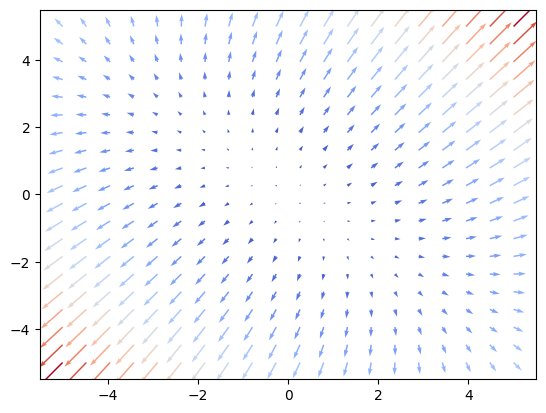

In [ ]:
# 생활 비유: “주방 바닥에 열기가 퍼져 있는 지도. 화살표는 ‘열기가 가장 빨리 퍼지는 방향’을 가리킨다.”
# 숫자 예시: 온도가 10→20으로 변하는 구간에서 화살표는 높은 쪽으로 향함.

import numpy as np
import matplotlib.pyplot as plt

X, Y = np.meshgrid(np.linspace(-5,5,20), np.linspace(-5,5,20))
Z = X**2 + X*Y + Y**2
dZdx = 2*X + Y
dZdy = 2*Y + X

plt.quiver(X, Y, dZdx, dZdy, Z, cmap='coolwarm')
plt.show()


### 💡 확인 문제: 012. Gradient Field (특정 단면에서의 기울기)

Q1. Gradient Field는 '오차라는 평원 위의 보물찾기 지도'에 비유될 때, 지도 위에 그려진 **수많은 화살표**들은 모델이 어디에 있든 오차를 \[ ] 줄일 수 있는 방향을 알려줍니다.

Q2. Gradient Field의 화살표들은 항상 가장 완만한 오차 감소 방향을 가리킨다. (O/X)

Q3. Gradient Field를 '오차라는 평원 위의 보물찾기 지도'에 비유했습니다. 이 지도 위에 그려진 '수많은 화살표'들은 무엇을 알려준다고 했나요?

### ✅ 정답

Q1. **가장 빠르게**

Q2. **X** (가장 가파른 오차 감소 방향을 가리킵니다.)

Q3. 모델이 지도 위의 어느 지점에 있든, 그 지점에서 오차를 **가장 빠르게 줄일 수 있는 방향**을 알려줍니다.

<!-- Deprecated: Questions moved to the main '확인 문제' cell above. -->

<!-- Deprecated: Answers moved to the main '정답' cell above. -->